# Wild Blueberry Regression Project

In this challenge, your goal is to build a machine learning model that forecasts wild blueberry harvest yields using key pollination and environmental indicators. Using a synthetic tabular dataset modeled on real biological research, competitors will analyze how factors like bee species dynamics and weather conditions influence crop output.

Models will be evaluated on Mean Absolute Error (MAE), rewarding predictions that closely align with true yield values. This competition offers a practical opportunity to refine your regression techniques, feature engineering strategies, and ensemble methods on realistic agricultural data.

<img src='https://www.frotzfruits.com/wp-content/uploads/2021/10/ARANDANO-AZUL-FROTZ-ETIQUETA.jpg' width='750'>

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

# EDA

In [2]:
df=pd.read_csv('train.csv')

In [3]:
df.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146
1,1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201
2,2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760
3,3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590
4,4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417


In [4]:
df.tail()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
15284,15284,12.5,0.25,0.25,0.38,0.50,77.4,46.8,64.7,55.8,27.0,45.8,16.0,0.26,0.556302,0.476308,40.546480,7667.83619
15285,15285,12.5,0.25,0.25,0.25,0.50,86.0,52.0,71.9,62.0,30.0,50.8,34.0,0.56,0.354413,0.388145,29.467434,3680.56025
15286,15286,25.0,0.50,0.25,0.38,0.75,77.4,46.8,64.7,55.8,27.0,45.8,34.0,0.56,0.422548,0.416786,32.299059,4696.44394
15287,15287,25.0,0.50,0.25,0.63,0.63,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.542170,0.434133,36.674243,6772.93347
15288,15288,25.0,0.50,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,16.0,0.26,0.492077,0.446576,35.094733,5867.99722


In [5]:
df.shape

(15289, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15289 entries, 0 to 15288
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15289 non-null  int64  
 1   clonesize             15289 non-null  float64
 2   honeybee              15289 non-null  float64
 3   bumbles               15289 non-null  float64
 4   andrena               15289 non-null  float64
 5   osmia                 15289 non-null  float64
 6   MaxOfUpperTRange      15289 non-null  float64
 7   MinOfUpperTRange      15289 non-null  float64
 8   AverageOfUpperTRange  15289 non-null  float64
 9   MaxOfLowerTRange      15289 non-null  float64
 10  MinOfLowerTRange      15289 non-null  float64
 11  AverageOfLowerTRange  15289 non-null  float64
 12  RainingDays           15289 non-null  float64
 13  AverageRainingDays    15289 non-null  float64
 14  fruitset              15289 non-null  float64
 15  fruitmass          

In [7]:
df.isnull().sum()

id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
yield                   0
dtype: int64

In [8]:
df.describe()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
count,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000,15289.000000
mean,7644.000000,19.704690,0.389314,0.286768,0.492675,0.592355,82.169887,49.673281,68.656256,59.229538,28.660553,48.568500,18.660865,0.324176,0.502741,0.446553,36.164950,6025.193999
std,4413.698468,6.595211,0.361643,0.059917,0.148115,0.139489,9.146703,5.546405,7.641807,6.610640,3.195367,5.390545,11.657582,0.163905,0.074390,0.037035,4.031087,1337.056850
min,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,69.700000,39.000000,58.200000,50.200000,24.300000,41.200000,1.000000,0.060000,0.192732,0.311921,22.079199,1945.530610
25%,3822.000000,12.500000,0.250000,0.250000,0.380000,0.500000,77.400000,46.800000,64.700000,55.800000,27.000000,45.800000,16.000000,0.260000,0.458246,0.419216,33.232449,5128.163510
50%,7644.000000,25.000000,0.500000,0.250000,0.500000,0.630000,86.000000,52.000000,71.900000,62.000000,30.000000,50.800000,16.000000,0.260000,0.506600,0.446570,36.040675,6117.475900
75%,11466.000000,25.000000,0.500000,0.380000,0.630000,0.750000,86.000000,52.000000,71.900000,62.000000,30.000000,50.800000,24.000000,0.390000,0.560445,0.474134,39.158238,7019.694380
max,15288.000000,40.000000,18.430000,0.585000,0.750000,0.750000,94.600000,57.200000,79.000000,68.200000,33.000000,55.900000,34.000000,0.560000,0.652144,0.535660,46.585105,8969.401840


In [9]:
df.corr(numeric_only=True)

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
id,1.000000,0.003041,0.013690,0.003244,0.008948,0.004693,0.009528,0.009613,0.009504,0.009756,0.009544,0.009608,0.002340,0.001703,0.006061,0.004760,0.000867,0.000975
clonesize,0.003041,1.000000,0.304130,0.080433,0.065131,-0.007607,0.016159,0.015838,0.016057,0.016343,0.016026,0.015987,0.165770,0.164823,-0.406793,-0.377688,-0.396898,-0.382619
honeybee,0.013690,0.304130,1.000000,-0.017937,0.030671,-0.010394,0.005840,0.005755,0.005892,0.005942,0.005809,0.005485,0.046494,0.037532,-0.120492,-0.135310,-0.139261,-0.118001
bumbles,0.003244,0.080433,-0.017937,1.000000,-0.164962,0.158001,-0.002104,-0.001813,-0.001769,-0.001613,-0.001804,-0.001644,-0.063294,-0.060232,0.160447,0.163987,0.177022,0.161145
andrena,0.008948,0.065131,0.030671,-0.164962,1.000000,0.309556,-0.013061,-0.012928,-0.012993,-0.012924,-0.013035,-0.013071,-0.026572,-0.027193,0.073669,0.064722,0.063504,0.073969
osmia,0.004693,-0.007607,-0.010394,0.158001,0.309556,1.000000,-0.031391,-0.030819,-0.031415,-0.031398,-0.031486,-0.031337,-0.079874,-0.078720,0.209495,0.192210,0.200597,0.198264
MaxOfUpperTRange,0.009528,0.016159,0.005840,-0.002104,-0.013061,-0.031391,1.000000,0.998599,0.999806,0.999503,0.999829,0.999772,0.011322,0.010352,0.007580,0.146237,0.060963,-0.022517
MinOfUpperTRange,0.009613,0.015838,0.005755,-0.001813,-0.012928,-0.030819,0.998599,1.000000,0.999004,0.998199,0.998953,0.999040,0.011727,0.010767,0.008409,0.147203,0.061812,-0.021929
AverageOfUpperTRange,0.009504,0.016057,0.005892,-0.001769,-0.012993,-0.031415,0.999806,0.999004,1.000000,0.999465,0.999973,0.999974,0.011245,0.010260,0.008503,0.147676,0.062082,-0.021940
MaxOfLowerTRange,0.009756,0.016343,0.005942,-0.001613,-0.012924,-0.031398,0.999503,0.998199,0.999465,1.000000,0.999489,0.999423,0.011302,0.010262,0.007902,0.146668,0.061378,-0.022197


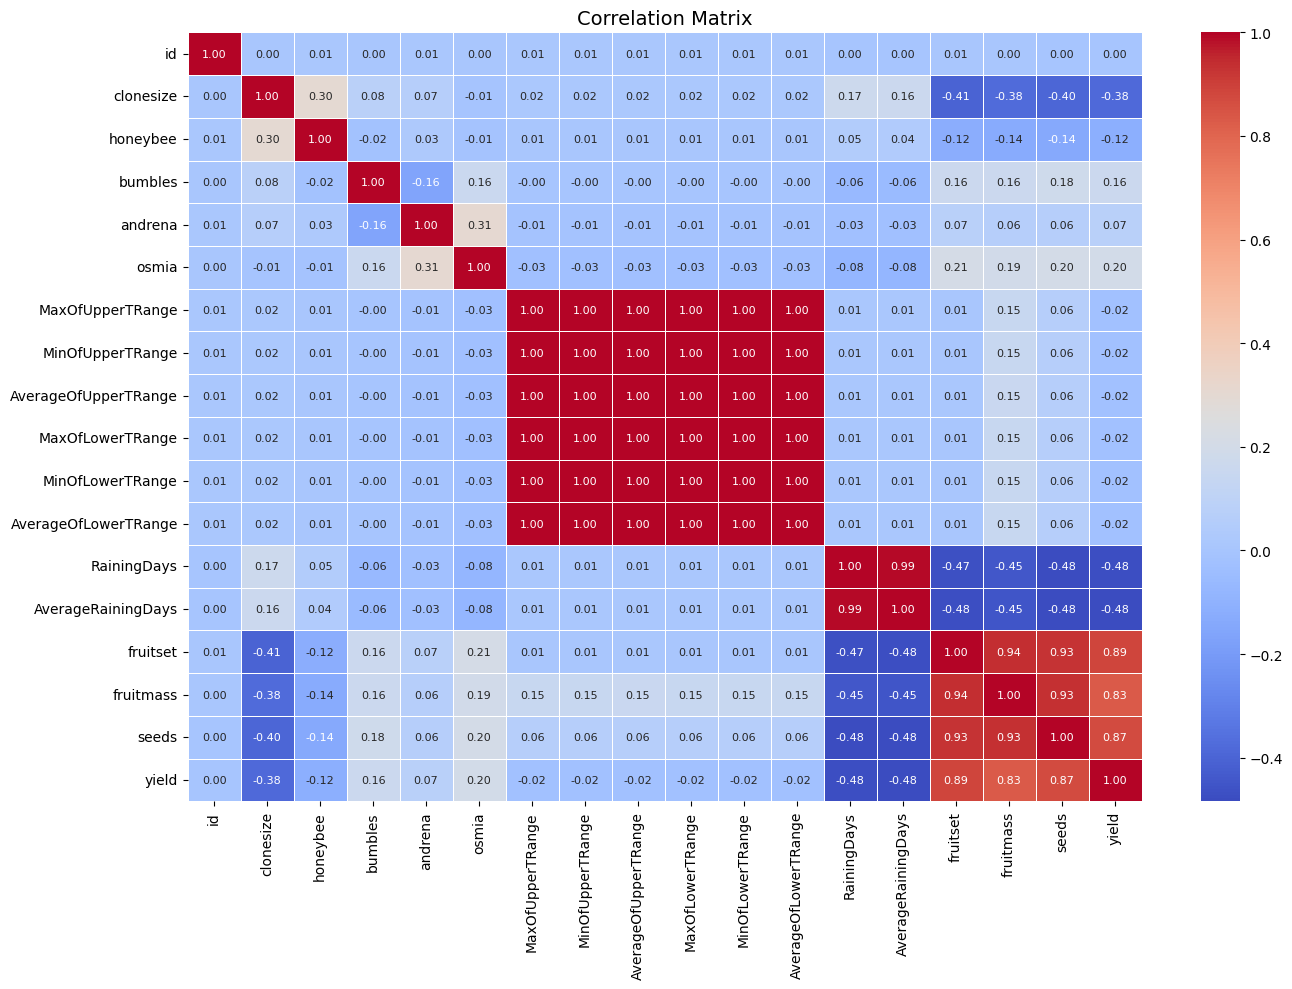

In [11]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 8},  
    linewidths=0.5, 
)

plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout() 
plt.show()

In [12]:
abs(df.corr(numeric_only=True)['yield'].sort_values(ascending=False))

yield                   1.000000
fruitset                0.885967
seeds                   0.868853
fruitmass               0.826481
osmia                   0.198264
bumbles                 0.161145
andrena                 0.073969
id                      0.000975
MinOfUpperTRange        0.021929
AverageOfUpperTRange    0.021940
AverageOfLowerTRange    0.022081
MaxOfLowerTRange        0.022197
MinOfLowerTRange        0.022319
MaxOfUpperTRange        0.022517
honeybee                0.118001
clonesize               0.382619
RainingDays             0.477191
AverageRainingDays      0.483870
Name: yield, dtype: float64

<Axes: >

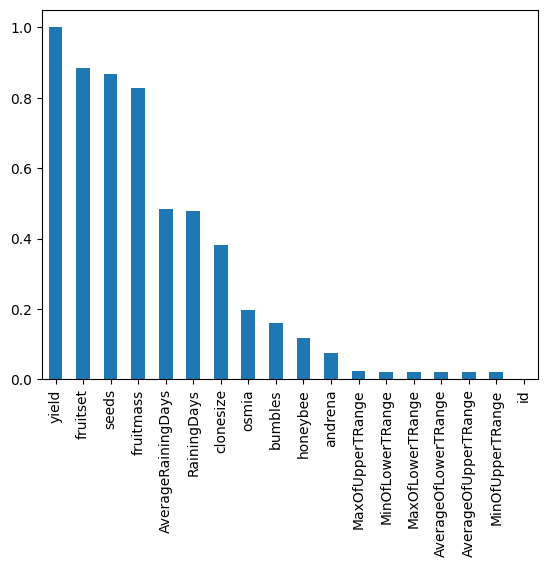

In [13]:
df.corr(numeric_only=True)["yield"].abs().sort_values(ascending=False).plot(
    kind="bar"
)

In [14]:
df = df.drop('id', axis=1)

array([[<Axes: title={'center': 'clonesize'}>,
        <Axes: title={'center': 'honeybee'}>,
        <Axes: title={'center': 'bumbles'}>,
        <Axes: title={'center': 'andrena'}>],
       [<Axes: title={'center': 'osmia'}>,
        <Axes: title={'center': 'MaxOfUpperTRange'}>,
        <Axes: title={'center': 'MinOfUpperTRange'}>,
        <Axes: title={'center': 'AverageOfUpperTRange'}>],
       [<Axes: title={'center': 'MaxOfLowerTRange'}>,
        <Axes: title={'center': 'MinOfLowerTRange'}>,
        <Axes: title={'center': 'AverageOfLowerTRange'}>,
        <Axes: title={'center': 'RainingDays'}>],
       [<Axes: title={'center': 'AverageRainingDays'}>,
        <Axes: title={'center': 'fruitset'}>,
        <Axes: title={'center': 'fruitmass'}>,
        <Axes: title={'center': 'seeds'}>],
       [<Axes: title={'center': 'yield'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

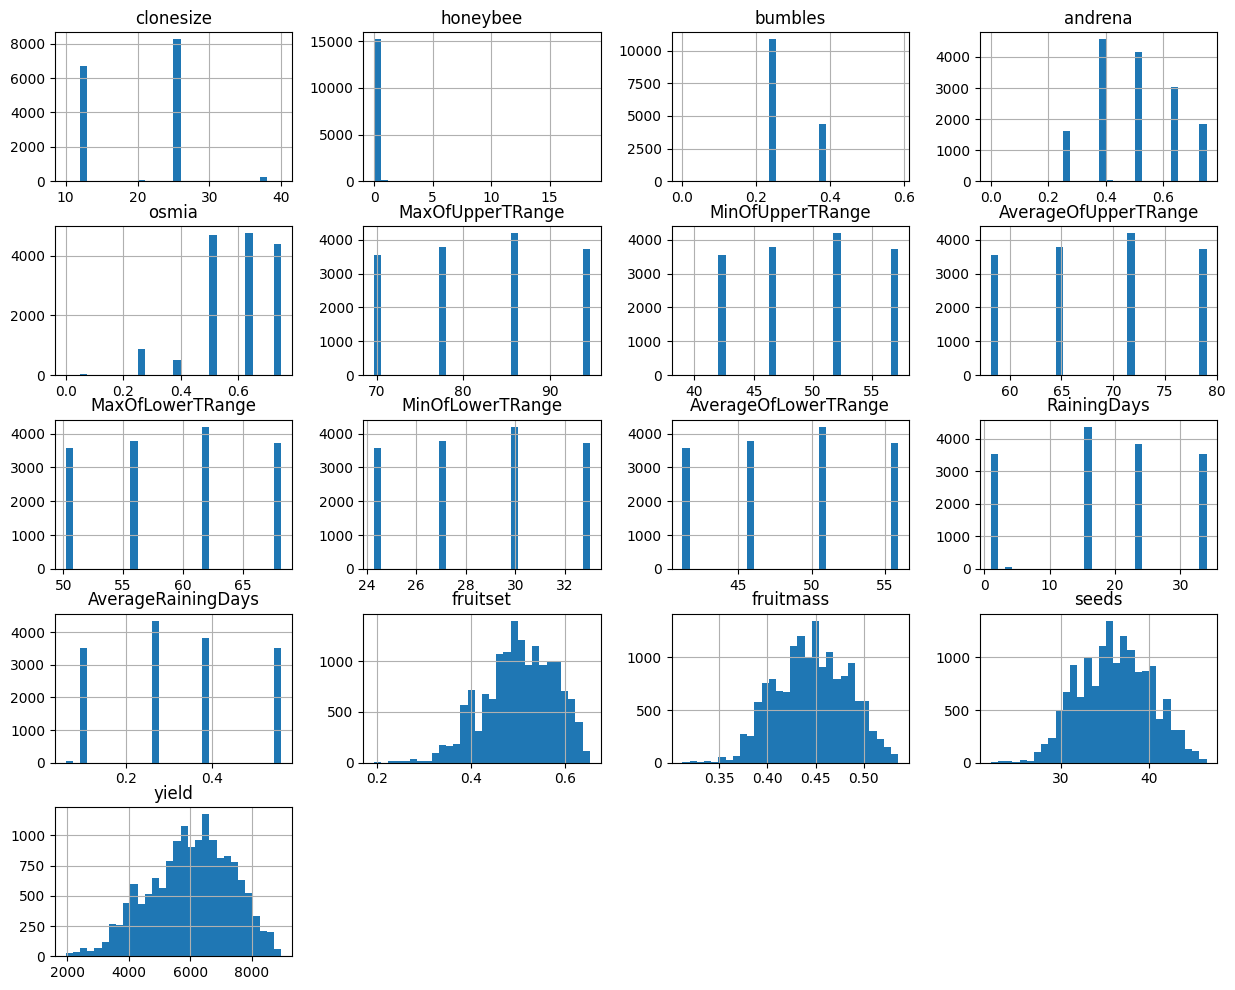

In [15]:
df.hist(figsize=(15, 12), bins=30)

clonesize                  Axes(0.125,0.747241;0.168478x0.132759)
honeybee                Axes(0.327174,0.747241;0.168478x0.132759)
bumbles                 Axes(0.529348,0.747241;0.168478x0.132759)
andrena                 Axes(0.731522,0.747241;0.168478x0.132759)
osmia                      Axes(0.125,0.587931;0.168478x0.132759)
MaxOfUpperTRange        Axes(0.327174,0.587931;0.168478x0.132759)
MinOfUpperTRange        Axes(0.529348,0.587931;0.168478x0.132759)
AverageOfUpperTRange    Axes(0.731522,0.587931;0.168478x0.132759)
MaxOfLowerTRange           Axes(0.125,0.428621;0.168478x0.132759)
MinOfLowerTRange        Axes(0.327174,0.428621;0.168478x0.132759)
AverageOfLowerTRange    Axes(0.529348,0.428621;0.168478x0.132759)
RainingDays             Axes(0.731522,0.428621;0.168478x0.132759)
AverageRainingDays          Axes(0.125,0.26931;0.168478x0.132759)
fruitset                 Axes(0.327174,0.26931;0.168478x0.132759)
fruitmass                Axes(0.529348,0.26931;0.168478x0.132759)
seeds     

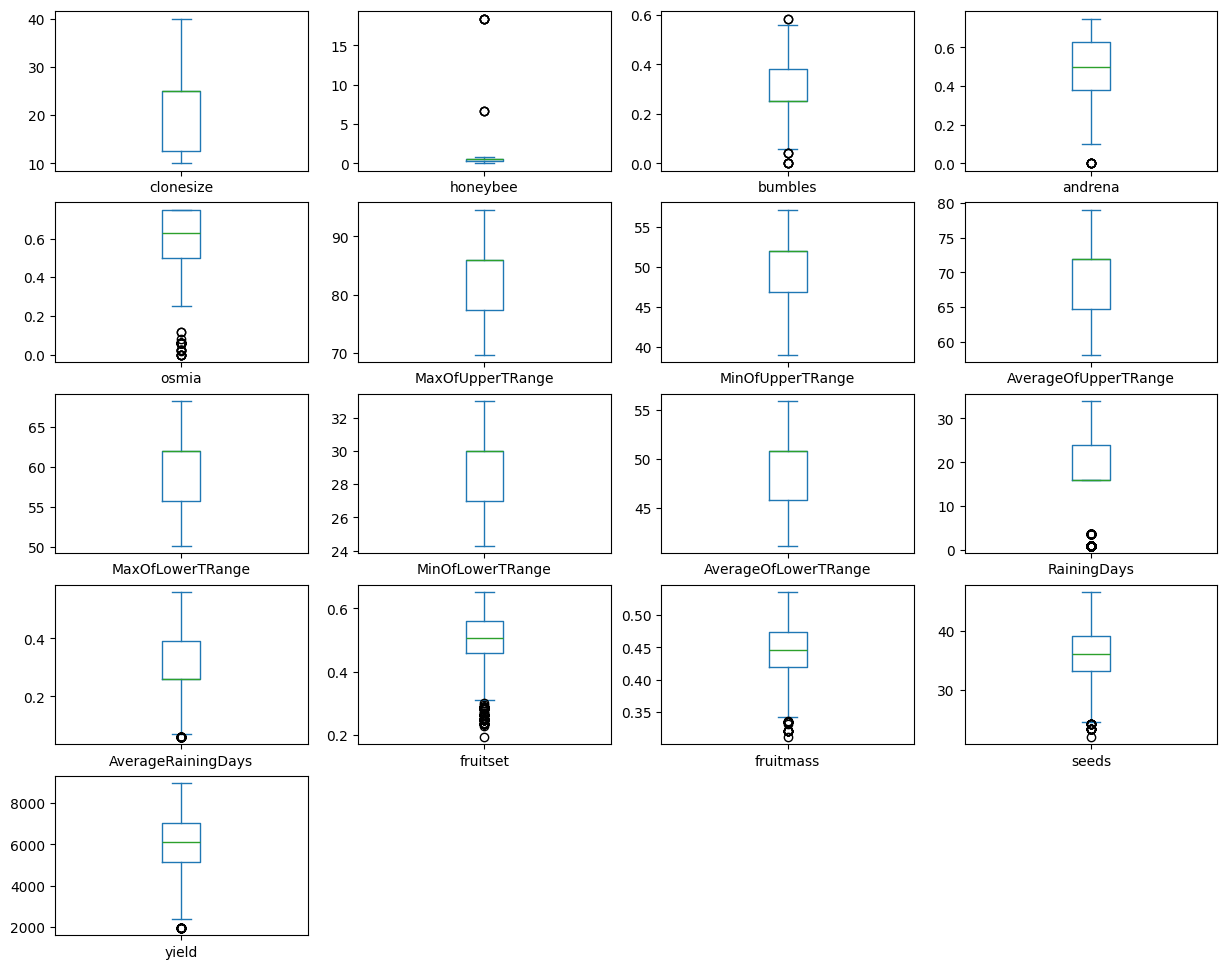

In [16]:
df.plot(kind="box", subplots=True, layout=(5, 4), figsize=(15, 12))

<Axes: xlabel='fruitset', ylabel='yield'>

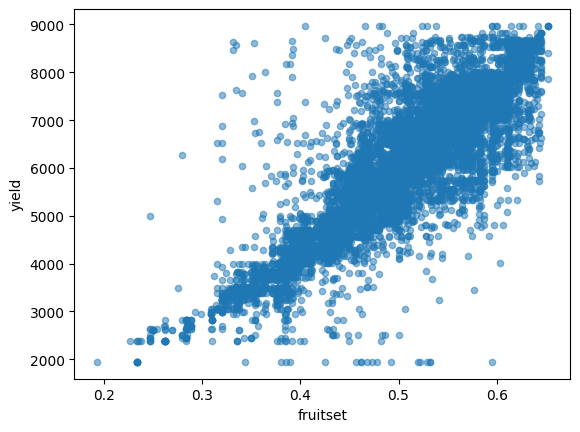

In [17]:
df.plot(
    kind="scatter",
    x="fruitset",
    y="yield",
    alpha=0.5,
) 

### Feature Engineering

In [18]:
def create_features(data):
    df = data.copy()

    # Bee features
    df["total_bees"] = (
        df["honeybee"] + df["bumbles"] + df["andrena"] + df["osmia"]
    )
    df["bee_diversity"] = (
        df[["honeybee", "bumbles", "andrena", "osmia"]] > 0
    ).sum(axis=1)

    # Temperature features
    df["upper_temp_range"] = df["MaxOfUpperTRange"] - df["MinOfUpperTRange"]
    df["lower_temp_range"] = df["MaxOfLowerTRange"] - df["MinOfLowerTRange"]
    df["overall_avg_temp"] = (
        df["AverageOfUpperTRange"] + df["AverageOfLowerTRange"]
    ) / 2
    df["temp_spread"] = df["AverageOfUpperTRange"] - df["AverageOfLowerTRange"]

    # Rain features
    df["bee_rain_impact"] = df["total_bees"] / (df["RainingDays"] + 1)

    # Fruit and seed interaction features (high correlation with target)
    df["fruit_mass_x_set"] = df["fruitset"] * df["fruitmass"]
    df["fruit_mass_x_seeds"] = df["fruitmass"] * df["seeds"]
    df["seeds_per_fruitmass"] = df["seeds"] / (df["fruitmass"] + 1e-5)

    return df


# Execution:
df_fe = create_features(df)

In [19]:
df_fe.corr()['yield'].abs().sort_values(ascending=False)

yield                   1.000000
fruitset                0.885967
fruit_mass_x_set        0.872650
seeds                   0.868853
fruit_mass_x_seeds      0.859986
fruitmass               0.826481
seeds_per_fruitmass     0.621891
AverageRainingDays      0.483870
RainingDays             0.477191
clonesize               0.382619
bee_rain_impact         0.351375
osmia                   0.198264
bumbles                 0.161145
honeybee                0.118001
andrena                 0.073969
upper_temp_range        0.023296
MaxOfUpperTRange        0.022517
MinOfLowerTRange        0.022319
MaxOfLowerTRange        0.022197
AverageOfLowerTRange    0.022081
lower_temp_range        0.022061
overall_avg_temp        0.021998
AverageOfUpperTRange    0.021940
MinOfUpperTRange        0.021929
temp_spread             0.021598
bee_diversity           0.015563
total_bees              0.012839
Name: yield, dtype: float64

### Modeling

In [31]:
x= df_fe.drop(['yield'], axis=1)

In [32]:
y = df_fe['yield']

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [35]:
x_train.shape

(12231, 26)

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
lr=LinearRegression()

In [38]:
model=lr.fit(x_train,y_train)

In [39]:
prediction=model.predict(x_test)

In [40]:
from sklearn.metrics import r2_score,mean_squared_error 

In [41]:
r2_score(y_test,prediction)

0.8134340920552061

In [42]:
mean_squared_error(y_test,prediction)**.5

572.687416601004

In [43]:
residuals= y_test-prediction

In [44]:
residuals

3519     1552.638103
6096     -469.828792
895      -151.074068
11345    -374.914477
7219     -445.291455
            ...     
14832     401.139868
8271      138.457700
14422      60.177465
9239       49.794141
9906     1351.594032
Name: yield, Length: 3058, dtype: float64

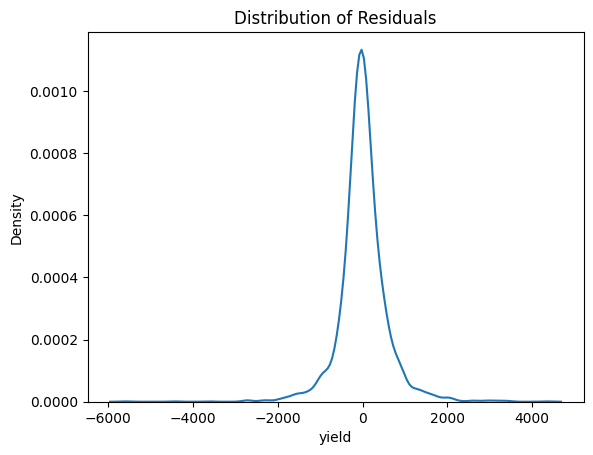

In [45]:
# If residuals is a Series or Array
sns.kdeplot(residuals)
plt.title('Distribution of Residuals')
plt.show()

In [46]:
from yellowbrick.regressor import ResidualsPlot

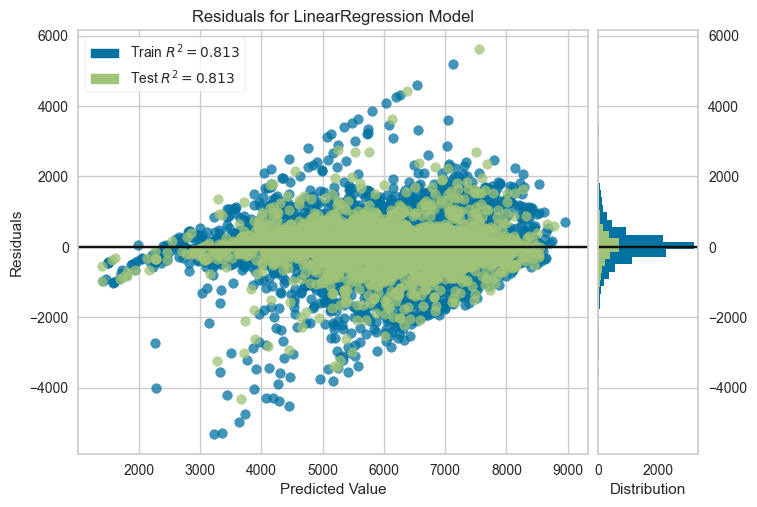

In [47]:
vis=ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show()
plt.show()

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
# pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x, y):
        # Initializing all regression models
        L = LinearRegression()
        R = Ridge()
        Lass = Lasso()
        E = ElasticNet()
        sgd = SGDRegressor()
        ETR = ExtraTreeRegressor()
        GBR = GradientBoostingRegressor()
        kn = KNeighborsRegressor()
        rkn = RadiusNeighborsRegressor(radius=1.0)
        ada = AdaBoostRegressor()
        dt = DecisionTreeRegressor()
        xgb = XGBRegressor()
        svr = SVR()
        mlp_regressor = MLPRegressor()

        algos = [L, R, Lass, E, sgd, ETR, GBR, ada, kn, dt, xgb, svr, mlp_regressor]
        algo_names = ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 'Extra Tree', 'Gradient Boosting',
                    'KNeighborsRegressor', 'AdaBoost', 'Decision Tree', 'XGBRegressor', 'SVR', 'MLP Regressor']
        
        # Scaling features using MinMaxScaler
        x = MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

        r_squared = []
        rmse = []
        mae = []

        # Creating a dataframe to store error metrics and accuracy rates
        result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)

        for algo in algos:
            # Fitting the model and making predictions
            p = algo.fit(x_train, y_train).predict(x_test)
            r_squared.append(r2_score(y_test, p))
            rmse.append(mean_squared_error(y_test, p)**.5)
            mae.append(mean_absolute_error(y_test, p))

        # Populating the result table with accuracy and error rates
        result.R_Squared = r_squared
        result.RMSE = rmse
        result.MAE = mae

        # Sorting the result table by R-Squared (accuracy) in descending order
        rtable = result.sort_values('R_Squared', ascending=False)
        return rtable

In [49]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.824025,556.194609,349.986058
Linear,0.813434,572.687417,369.525528
Ridge,0.810128,577.740055,371.328236
Lasso,0.809301,578.996140,371.889240
XGBRegressor,0.807470,581.768571,372.275895
SGD,0.805603,584.583821,376.790206
MLP Regressor,0.787036,611.863039,405.447871
AdaBoost,0.773287,631.306014,434.832807
KNeighborsRegressor,0.646314,788.515479,577.684594
Extra Tree,0.639214,796.390666,525.073647


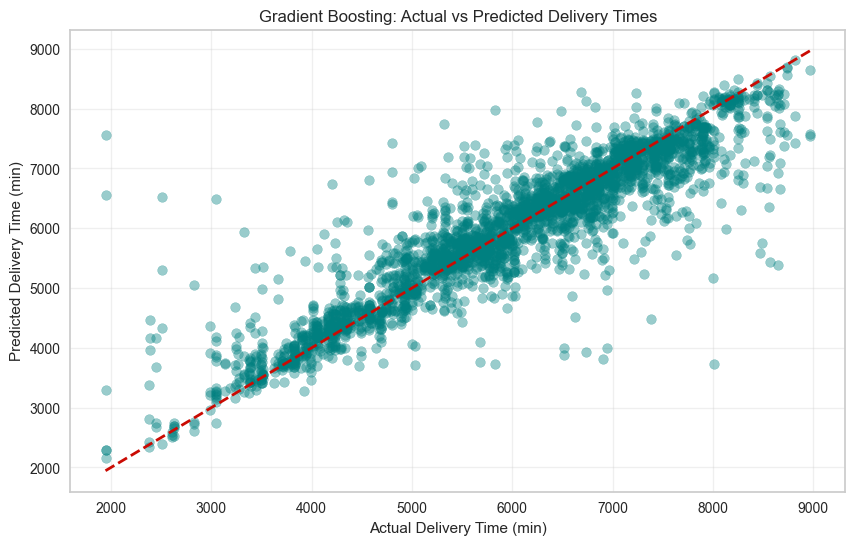

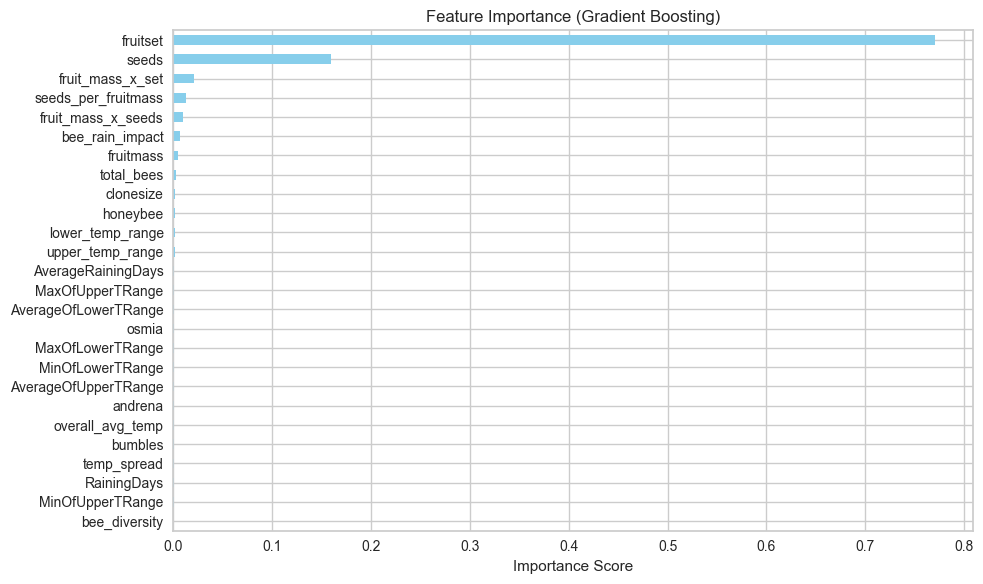

In [50]:
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import pandas as pd

# 1. Train the winning model (Gradient Boosting)
# Using the scaled data from our preprocessing step
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(x_train, y_train)
prediction = model.predict(x_test)

# 2. Visualizing Prediction vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, prediction, alpha=0.4, color='teal') 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title('Gradient Boosting: Actual vs Predicted Delivery Times')
plt.grid(alpha=0.3)
plt.show()

# 3. Feature Importance
plt.figure(figsize=(10, 6))
# Using x.columns from your original feature set
importances = pd.Series(model.feature_importances_, index=x.columns)
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance (Gradient Boosting)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [51]:
import joblib

# Save the model
joblib.dump(model, 'blueberry_model.pkl')

['blueberry_model.pkl']

This project successfully demonstrates a robust machine learning pipeline for predicting wild blueberry yields using a synthetic dataset modeled after real-world agricultural observations. By benchmarking multiple regression algorithms—ranging from linear models to advanced tree-based ensembles—Gradient Boosting Regressor emerged as the top-performing model, achieving the highest performance metrics with an $R^2$ score of 0.824, a Mean Absolute Error (MAE) of 349.99, and a Root Mean Squared Error (RMSE) of 556.19. The feature analysis underscores that pollination dynamics (such as honeybee and bumblebee activity) and core fruit traits (e.g., fruitset and seeds) serve as the strongest predictors of overall crop output. Ultimately, this data-driven framework provides actionable insights for estimating agricultural output, enabling optimized farm management and more precise revenue forecasting. 